# JavaFX in JupyterLab (same pipeline as Swing)

JavaFX rides the **same** interactive pipeline as Swing: a `javafx.embed.swing.JFXPanel` embeds an FX
scene and is itself a Swing `JComponent`, so `displayInteractive(...)` snapshots it and forwards
mouse/keyboard into the FX scene. You can pass a `JFXPanel` **or** a bare `javafx.scene.Node`
(it gets wrapped in a `JFXPanel` automatically).

**Prerequisites**
- The `jjava-swing` JupyterLab extension installed + the JJava kernel reinstalled (interactivity).
  Without the extension you still get a static snapshot.
- **JavaFX is an optional, user-supplied dependency.** Cell 1 pulls OpenJFX via `%maven` using the
  **platform classifier** (`linux` here; use `mac`, `mac-aarch64`, or `win` as appropriate).
- A display is required (your machine has one). On a headless server, JavaFX needs Monocle
  (`-Dglass.platform=Monocle -Dmonocle.platform=Headless`) — unlike Swing, which is headless-native.

Build the FX scene graph on the **JavaFX Application Thread** (`Platform.runLater(...)`).

> **Note:** with `%maven` you'll see `Unsupported JavaFX configuration: classes were loaded from 'unnamed module ...'`. This is a harmless JavaFX warning (OpenJFX is on the classpath, not the module path) - FX still works. To silence it, instead launch the kernel with the OpenJFX SDK on the module path: `JJAVA_JVM_OPTS="--module-path /path/to/javafx-sdk/lib --add-modules javafx.controls,javafx.swing"` and skip the `%maven` cell.

## 1. Pull OpenJFX and boot the toolkit

In [6]:
// Pull OpenJFX (edit the classifier for your OS: linux | mac | mac-aarch64 | win)
%maven org.openjfx:javafx-base:jar:linux:21.0.2
%maven org.openjfx:javafx-graphics:jar:linux:21.0.2
%maven org.openjfx:javafx-controls:jar:linux:21.0.2
%maven org.openjfx:javafx-swing:jar:linux:21.0.2

import javafx.embed.swing.JFXPanel;
new JFXPanel(); // boots the JavaFX toolkit
System.out.println("JavaFX runtime: " + System.getProperty("javafx.runtime.version"));

JavaFX runtime: 21.0.2+5


## 2. A JavaFX form via JFXPanel (click Greet, type in the field)

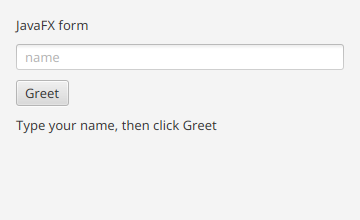

In [7]:
import javafx.embed.swing.JFXPanel;
import javafx.application.Platform;
import javafx.scene.Scene;
import javafx.scene.control.Button;
import javafx.scene.control.Label;
import javafx.scene.control.TextField;
import javafx.scene.layout.VBox;
import javafx.geometry.Insets;

// A JavaFX form embedded via JFXPanel -> the existing interactive pipeline handles it.
JFXPanel fxForm = new JFXPanel();
Platform.runLater(() -> {
    Label out = new Label("Type your name, then click Greet");
    TextField name = new TextField();
    name.setPromptText("name");
    Button greet = new Button("Greet");
    greet.setOnAction(e -> out.setText("Hello, " + name.getText() + "!"));
    VBox box = new VBox(10, new Label("JavaFX form"), name, greet, out);
    box.setPadding(new Insets(16));
    fxForm.setScene(new Scene(box, 360, 220));
});

displayInteractive(fxForm);

## 3. Pass a bare JavaFX Node (auto-wrapped in a JFXPanel)

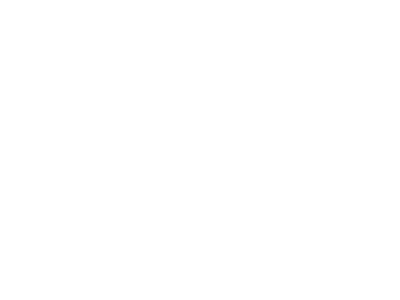

In [8]:
import javafx.application.Platform;
import javafx.scene.control.Button;
import javafx.scene.layout.StackPane;
import java.util.concurrent.CountDownLatch;

// You can also pass a JavaFX Node directly: displayInteractive(...) wraps it in a JFXPanel for you.
StackPane[] holder = new StackPane[1];
CountDownLatch ready = new CountDownLatch(1);
Platform.runLater(() -> {
    Button b = new Button("Click me (bare FX node)");
    b.setOnAction(e -> b.setText("Clicked!"));
    StackPane root = new StackPane(b);
    root.setPrefSize(320, 160);
    holder[0] = root;
    ready.countDown();
});
ready.await();

displayInteractive(holder[0]);

## 4. An animated FX scene (streams continuously)

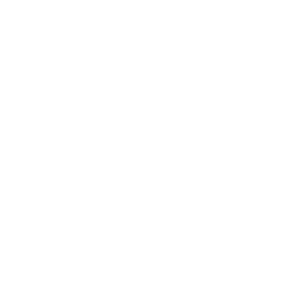

In [4]:
import javafx.embed.swing.JFXPanel;
import javafx.application.Platform;
import javafx.scene.Scene;
import javafx.scene.layout.StackPane;
import javafx.scene.shape.Rectangle;
import javafx.scene.paint.Color;
import javafx.animation.RotateTransition;
import javafx.animation.Animation;
import javafx.util.Duration;

// A continuously-animating FX scene -> exercises continuous frame streaming through the same pipeline.
JFXPanel fxAnim = new JFXPanel();
Platform.runLater(() -> {
    Rectangle rect = new Rectangle(90, 90, Color.CORNFLOWERBLUE);
    StackPane root = new StackPane(rect);
    root.setPrefSize(300, 300);
    RotateTransition rt = new RotateTransition(Duration.seconds(2), rect);
    rt.setByAngle(360);
    rt.setCycleCount(Animation.INDEFINITE);
    rt.play();
    fxAnim.setScene(new Scene(root, 300, 300));
});

displayInteractive(fxAnim);